In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


from pathlib import Path
import sys
project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.data_preprocessing import data_split
from utils.evaluate_model import evaluate_model
from src.learning_curve_plot import plot_learning_curve
from src.r2_comparison_plot import r2_comparison_plot

df = pd.read_csv('../data/processed/processed_data.csv', parse_dates=['Date'])

FEATURE_COLS = [
    'CPI_Change_lag1', 'Rate_Change', 'GDP_Growth_lag2', 'Unemp_Change_lag1',
    'USD_Change', 'VIX_Change', 'Credit_Spread_lag2']

splits_data = data_split(df, FEATURE_COLS)
X_train= splits_data['X_train']
y_train     = splits_data['y_train']
X_test  = splits_data['X_test']
y_test      = splits_data['y_test']
dates_test = splits_data['dates_test']

print(f"  Training samples : {len(X_train)}")
print(f"  Test samples     : {len(X_test)}")
print(f"  Features         : {len(FEATURE_COLS)}")


  Features (7): CPI_Change_lag1, Rate_Change, GDP_Growth_lag2, Unemp_Change_lag1, USD_Change, VIX_Change, Credit_Spread_lag2
  Training samples : 346
  Test samples     : 69
  Features         : 7



Random Forest Baseline Params
  n_estimators          : 100
  max_depth             : 3
  min_samples_split     : 20
  min_samples_leaf      : 10
  max_features          : sqrt
  max_samples           : 0.5

Training Random Forest Baseline ──
  Random Forest Baseline
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.3048     0.1857
  RMSE (%)                       3.403      4.529
  MAE (%)                        2.498      3.567
  Directional Acc (%)            76.59      73.91


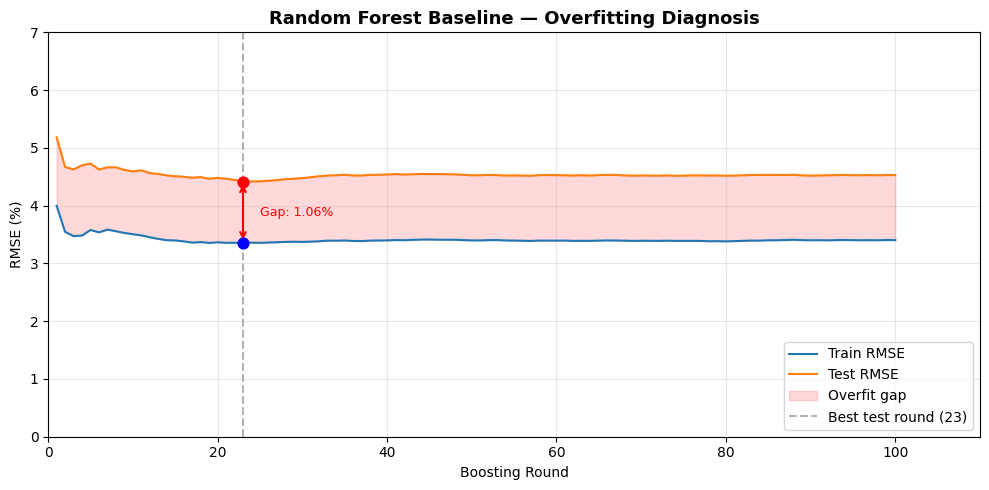

  Best round: 23  |  Train RMSE: 3.3580  |  Test RMSE: 4.4179  |  Gap: 1.0599


In [ ]:
# RF_PARAMS = {
#     'n_estimators'     : 300,
#     'max_depth'        : 8,
#     'min_samples_split': 20,
#     'min_samples_leaf' : 10,
#     'max_features'     : 0.5,
#     'bootstrap'        : True,
#     'oob_score'        : True,
#     'n_jobs'           : -1,
# }

RF_PARAMS = {
    'n_estimators'     : 100,
    'max_depth'        : 3,
    'min_samples_split': 20,    
    'min_samples_leaf' : 10, 

    'max_features'     : 'sqrt',

    'max_samples'      : 0.5,
}

print("\nRandom Forest Baseline Params")
for k, v in RF_PARAMS.items():
    print(f"  {k:<22}: {v}")


print("\nTraining Random Forest Baseline ──")
rf_model = RandomForestRegressor(**RF_PARAMS)
rf_model.fit(X_train, y_train)


ev_rf_base = evaluate_model(
        rf_model, X_train, y_train,
        X_test, y_test, "Random Forest Baseline"
    )

def collect_rf_learning_curve(rf_model, X_train, y_train, X_test, y_test):
    """Build per-tree train/test RMSE, matching XGBoost's evals_result format."""
    from sklearn.metrics import mean_squared_error

    train_rmse, test_rmse = [], []
    train_sum = np.zeros(len(y_train))
    test_sum  = np.zeros(len(y_test))

    for i, tree in enumerate(rf_model.estimators_, 1):
        train_sum += tree.predict(X_train)
        test_sum  += tree.predict(X_test)

        train_rmse.append(np.sqrt(mean_squared_error(y_train, train_sum / i)))
        test_rmse.append(np.sqrt(mean_squared_error(y_test,  test_sum / i)))

    return {'train': {'rmse': train_rmse}, 'test': {'rmse': test_rmse}}


rf_evals = collect_rf_learning_curve(rf_model, X_train, y_train, X_test, y_test)
plot_learning_curve(rf_evals, model_name="Random Forest Baseline")


In [20]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)


def objective(trial):
    params = {
        'n_estimators':      trial.suggest_int('n_estimators', 50, 500, step=25),
        'max_depth':         trial.suggest_int('max_depth', 2, 12),
        'min_samples_split': trial.suggest_int('min_samples_split', 5, 50),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 3, 30),
        'max_features':      trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
        'max_samples':       trial.suggest_float('max_samples', 0.3, 0.9),
        'n_jobs':            -1,
    }

    model = RandomForestRegressor(**params)
    model.fit(X_train, y_train)

    test_pred = model.predict(X_test)
    rmse = np.sqrt(mean_squared_error(y_test, test_pred))

    return rmse   # Optuna minimises by default


study = optuna.create_study(direction='minimize', study_name='rf_tuning')
study.optimize(objective, n_trials=100, show_progress_bar=True)


# ── Results ──
print("\nBest RMSE:", f"{study.best_value:.4f}")
print("\nBest Params:")
for k, v in study.best_params.items():
    print(f"  {k:<22}: {v}")

Best trial: 84. Best value: 4.10136: 100%|██████████| 100/100 [00:13<00:00,  7.59it/s]


Best RMSE: 4.1014

Best Params:
  n_estimators          : 50
  max_depth             : 5
  min_samples_split     : 6
  min_samples_leaf      : 3
  max_features          : 0.7
  max_samples           : 0.5170205478047262


  RF Optuna-Tuned
  Metric                         Train       Test
  ---------------------------------------------
  R²                            0.5060     0.3245
  RMSE (%)                       2.868      4.125
  MAE (%)                        2.145      3.247
  Directional Acc (%)            79.48      73.91


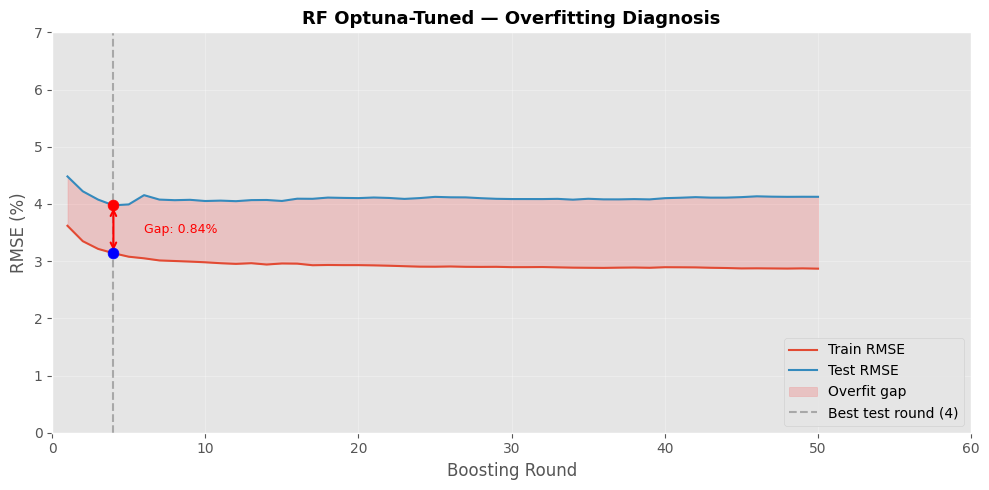

  Best round: 4  |  Train RMSE: 3.1387  |  Test RMSE: 3.9753  |  Gap: 0.8367


In [ ]:
best_params = study.best_params
best_params['n_jobs'] = -1

rf_tuned = RandomForestRegressor(**best_params)
rf_tuned.fit(X_train, y_train)

ev_rf_tuned = evaluate_model(rf_tuned, X_train, y_train, X_test, y_test, "RF Optuna-Tuned")

# Learning curve
rf_evals = collect_rf_learning_curve(rf_tuned, X_train, y_train, X_test, y_test)
plot_learning_curve(rf_evals, model_name="RF Optuna-Tuned")

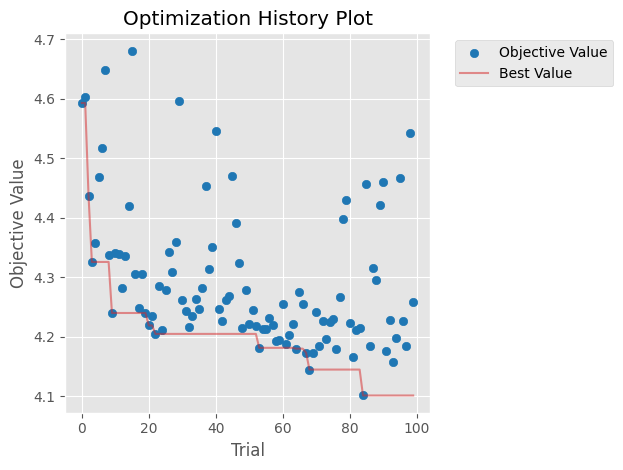

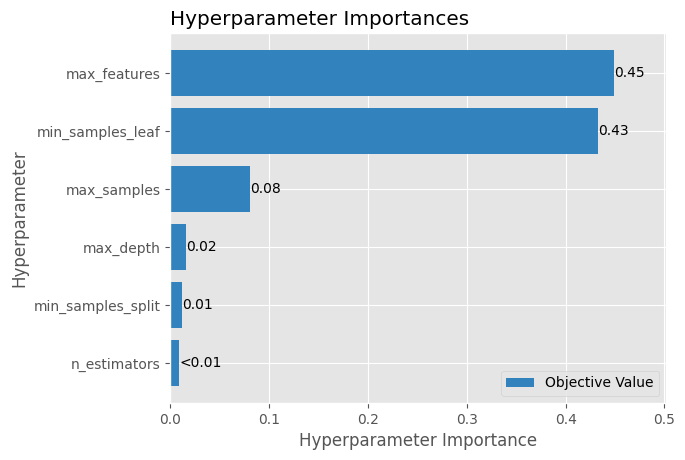

In [22]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

plot_optimization_history(study)
plt.show()

plot_param_importances(study)
plt.show()

In [29]:
imp_df = pd.DataFrame({
    'Feature' : FEATURE_COLS,
    'Importance': rf_tuned.feature_importances_
}).sort_values('Importance', ascending=False)
imp_df['Importance_pct'] = imp_df['Importance'] * 100

print("\n── Feature Importance (Mean Decrease in Impurity) ──")
print(imp_df.to_string(index=False))


── Feature Importance (Mean Decrease in Impurity) ──
           Feature  Importance  Importance_pct
        VIX_Change    0.561379       56.137888
Credit_Spread_lag2    0.099828        9.982849
        USD_Change    0.098096        9.809587
   GDP_Growth_lag2    0.068666        6.866570
       Rate_Change    0.065592        6.559153
 Unemp_Change_lag1    0.058559        5.855942
   CPI_Change_lag1    0.047880        4.788011


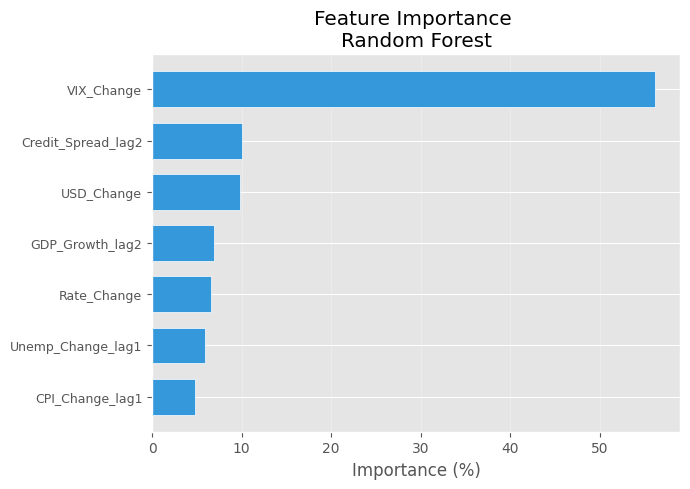

In [30]:
def plot_feature_importance_rf(imp_df):
    """Horizontal bar chart of mean decrease in impurity."""
    fig, ax = plt.subplots(figsize=(7, 5))
    imp_plot = imp_df.sort_values('Importance_pct')


    ax.barh(range(len(imp_plot)), imp_plot['Importance_pct'],
            color='#3498db', edgecolor='white', height=0.7)
    ax.set_yticks(range(len(imp_plot)))
    ax.set_yticklabels(imp_plot['Feature'], fontsize=9)
    ax.set_title('Feature Importance \nRandom Forest')
    ax.set_xlabel('Importance (%)')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

plot_feature_importance_rf(imp_df)

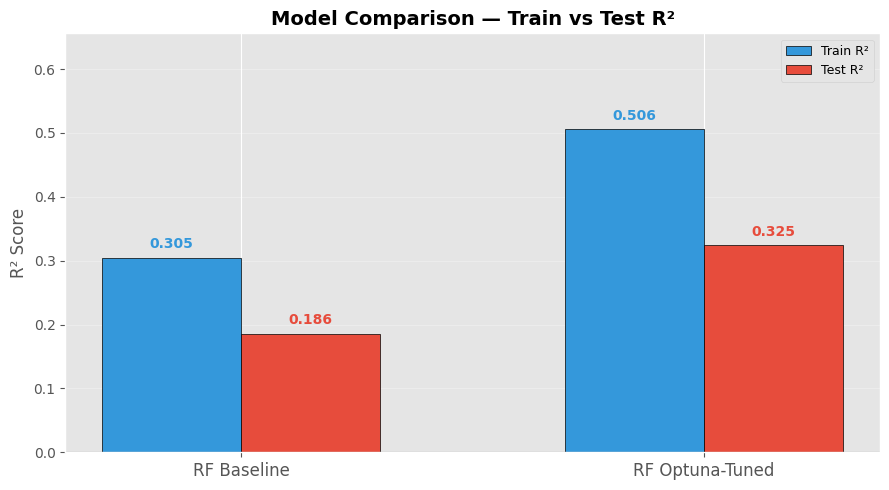

In [33]:

r2_comparison_plot({
    "RF Baseline":     ev_rf_base,
    "RF Optuna-Tuned": ev_rf_tuned,
})